# Multiclass Logistic Regression (LR)

# One vs All (OvR)

# Iris 
<img src="https://miro.medium.com/v2/resize:fit:808/1*YVMDQPEh8vD-AfiAS3G82Q.png" alt="iris image">

### Data set 
<a href = "https://www.kaggle.com/datasets/uciml/iris"> Kaggle </a>

In [1]:
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
iris = sns.load_dataset('iris')

In [3]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
encoder = LabelEncoder()
iris['species'] = encoder.fit_transform(iris['species'])

In [5]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
iris["species"].nunique()

3

In [7]:
X = iris.iloc[:,0:2]
y=iris.iloc[:,-1]

In [8]:
X

,sepal_length,sepal_width
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6
...,...,...
145,6.7,3.0
146,6.3,2.5
147,6.5,3.0
148,6.2,3.4


In [9]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 150, dtype: int64

In [10]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2, random_state=2)

In [11]:
ovrlr = OneVsRestClassifier(LogisticRegression())

In [12]:
ovrlr.fit(X_train,y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegression()
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](3,)","[0,1,2]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[LogisticRegression(), LogisticRegression(), LogisticRegression()]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['sepal_length','sepal_width']"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,2


In [13]:
y_pred = ovrlr.predict(X_test)

In [14]:
y_pred

array([0, 0, 1, 0, 0, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 2, 1, 1, 2, 1, 2, 2,
       2, 1, 1, 0, 0, 2, 0, 2])

In [15]:
y_test

6      0
3      0
113    2
12     0
24     0
129    2
25     0
108    2
128    2
45     0
48     0
42     0
35     0
5      0
85     1
54     1
41     0
96     1
144    2
89     1
77     1
74     1
115    2
94     1
87     1
29     0
2      0
127    2
44     0
125    2
Name: species, dtype: int64

In [16]:
y_prob = ovrlr.predict_proba(X_test)

In [17]:
y_prob

array([[0.82554551, 0.15724805, 0.01720644],
       [0.7246749 , 0.25635839, 0.01896671],
       [0.04624375, 0.6826599 , 0.27109634],
       [0.65376872, 0.31433526, 0.03189602],
       [0.81398487, 0.1592758 , 0.02673933],
       [0.00229047, 0.27471689, 0.72299264],
       [0.6035412 , 0.3435719 , 0.0528869 ],
       [0.00176427, 0.45669095, 0.54154478],
       [0.01443018, 0.43898296, 0.54658686],
       [0.65376872, 0.31433526, 0.03189602],
       [0.84027646, 0.09029255, 0.06943099],
       [0.77189518, 0.21636506, 0.01173975],
       [0.71242373, 0.2407923 , 0.04678397],
       [0.86668506, 0.05711373, 0.07620121],
       [0.35201543, 0.23894237, 0.40904221],
       [0.01034532, 0.41878085, 0.57087383],
       [0.36265278, 0.61439692, 0.02295029],
       [0.18272377, 0.53298223, 0.28429399],
       [0.03391989, 0.22366486, 0.74241525],
       [0.08364633, 0.71436077, 0.2019929 ],
       [0.01132818, 0.32369767, 0.66497415],
       [0.02106398, 0.40845076, 0.57048526],
       [0.

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8


In [19]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[13  1  0]
 [ 0  4  4]
 [ 0  1  7]]


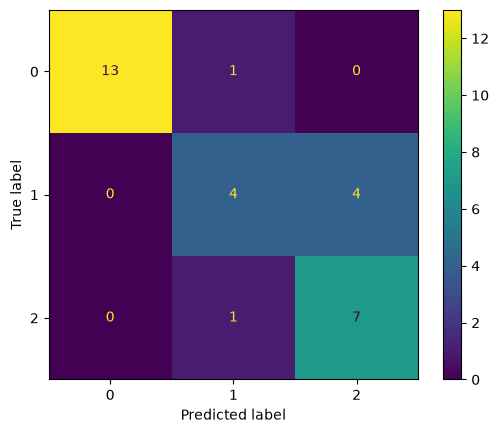

In [20]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [21]:
query = pd.DataFrame(
    [[3.4,2.7]],
    columns=X_train.columns
)

prediction = ovrlr.predict(query)
print(ovrlr.predict_proba(query))
print("Predicted class:", prediction[0])

[[0.63589801 0.36266044 0.00144155]]
Predicted class: 0


In [22]:
# %pip install mlxtend

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


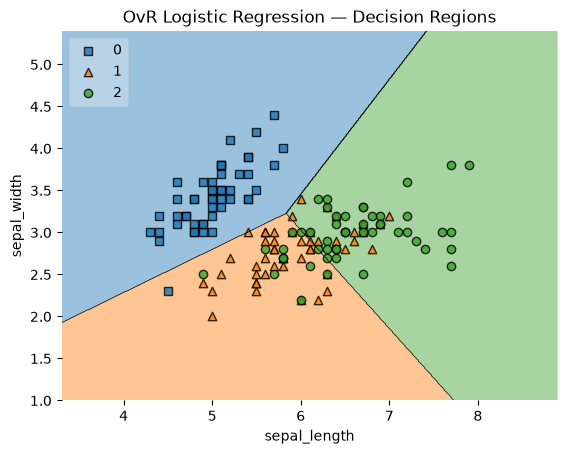

In [23]:
from mlxtend.plotting import plot_decision_regions

X_plot = X.iloc[:, [0, 1]]
y_plot = y

plot_decision_regions(
    X_plot.values,
    y_plot.values,
    clf=ovrlr,
    legend=2
)

plt.xlabel(X_plot.columns[0])
plt.ylabel(X_plot.columns[1])
plt.title("OvR Logistic Regression — Decision Regions")
plt.show()